## 数据导入

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
colors = sns.color_palette('husl')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from snownlp import SnowNLP

import warnings
warnings.filterwarnings('ignore')

import jieba.analyse
from pyecharts.charts import WordCloud
import jieba

In [2]:
data_1 = pd.read_csv('部分用户信息.csv', encoding='utf-8')
data_2 = pd.read_csv('wukong.csv', encoding='utf-8')
data = pd.merge(data_1, data_2, how='right', on='用户链接')
data = data.fillna('')

In [3]:
print(data.shape)
print(data.columns)
data.columns = ['user_link', 'user_name_n', 'user_nationality', 'user_level', 'user_badge',
                'user_games', 'user_achievement', 'user_name', 'comment_date', 'recommend', 'score',
                'comment']
data.drop(columns=['user_name_n'], inplace=True)
data.head(5)

(15871, 12)
Index(['用户链接', '用户名', '用户游戏国籍', '用户等级', '用户持有徽章数', '用户持有游戏数', '用户持有成就数', '用户',
       '发布时间(2024年)', '是否推荐', '大圣游戏时长', '评论'],
      dtype='object')


,user_link,user_nationality,user_level,user_badge,user_games,user_achievement,user_name,comment_date,recommend,score,comment
0,https://steamcommunity.com/profiles/7656119812...,"Cox's Bazar, Bangladesh",52.0,24,138,25,Solaire,8月20日,推荐,10.5,\n\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t开服前：最多3天必定拿下...
1,https://steamcommunity.com/profiles/7656119835...,"Changzhou, Jiangsu, China",20.0,7,96,96,洪七公,8月19日,推荐,13.2,\n\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t一从大地起风雷，便有精生...
2,https://steamcommunity.com/profiles/7656119810...,China,16.0,9,86,,上条利露,8月19日,推荐,6.9,\n\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t我曾在莫哈维的沙漠当过邮...
3,https://steamcommunity.com/profiles/7656119814...,"Yunnan, China",131.0,428,"1,748",28,sadness,8月19日,推荐,21.1,\n\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t回想四年前的今天，如同梦...
4,https://steamcommunity.com/id/xxxibgdrgn5421/,China,51.0,75,517,58,xxxibgdrgn,8月19日,推荐,3.5,\n\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t你曾在西奈沙漠骑过战马；...


## 数据预处理


### 数据缺失、重复值处理

In [4]:
print('数据缺失值情况为：')
print(data.isnull().sum())
print('数据重复值情况为：')
print(data.duplicated().sum())
data = data.drop_duplicates()
print('去重后数据重复值情况为：')
print(data.duplicated().sum())

数据缺失值情况为：
user_link           0
user_nationality    0
user_level          0
user_badge          0
user_games          0
user_achievement    0
user_name           0
comment_date        0
recommend           0
score               0
comment             0
dtype: int64
数据重复值情况为：
10
去重后数据重复值情况为：
0


### 列处理

In [5]:
def get_user_id(link):
    link_temp = link.split('https://steamcommunity.com/')[1]
    if 'profiles' in link_temp:
        link_temp = link_temp.replace('profiles/', '')
    elif 'id' in link_temp:
        link_temp = link_temp.replace('id/', '')
    return link_temp[:-1]

In [6]:
def clear_t(string_content):
    string = str(string_content)
    string = string.replace('\\t', '')
    string = string.replace('\t', '')
    string = string.replace('\\n', '')
    string = string.replace('\n', '')
    string = string.replace('\\r', '')
    string = string.replace('\r', '')
    return string

In [7]:
def clear_comma(string_content):
    string = str(string_content).replace(',', '')
    return string

In [8]:
data = data.reset_index(drop=True)
data['user_id'] = ''
for i in data.index:
    # print(i)
    # 用户等级 user_level
    if data['user_level'][i] is not None and data['user_level'][i] != '':
        data['user_level'][i] = eval(clear_comma(data['user_level'][i]))
    else:
        data['user_level'][i] = -1

    # 用户徽章 user_badge
    if data['user_badge'][i] is not None and data['user_badge'][i] != '':
        data['user_badge'][i] = eval(clear_comma(data['user_badge'][i]))
    else:
        data['user_badge'][i] = -1

    # 用户游戏 user_games
    if data['user_games'][i] is not None and data['user_games'][i] != '':
        data['user_games'][i] = eval(clear_comma(data['user_games'][i]))
    else:
        data['user_games'][i] = -1

    # 用户 id user_id
    data['user_id'][i] = get_user_id(data['user_link'][i])

    # 评论日期 comment_date
    data['comment_date'][i] = '2024年' + str(data['comment_date'][i])

    # 是否推荐 recommend
    if data['recommend'][i] == '推荐':
        data['recommend'][i] = 1
    elif data['recommend'][i] == '不推荐':
        data['recommend'][i] = 0

    # 评价 comment
    data['comment'][i] = clear_t(data['comment'][i])

In [9]:
data['user_level'] = data['user_level'].astype(int)
data['user_badge'] = data['user_badge'].astype(int)
data['user_games'] = data['user_games'].astype(int)
data['recommend'] = data['recommend'].astype(int)
data.columns

Index(['user_link', 'user_nationality', 'user_level', 'user_badge',
       'user_games', 'user_achievement', 'user_name', 'comment_date',
       'recommend', 'score', 'comment', 'user_id'],
      dtype='object')

### 异常值情况

In [10]:
data.describe()

,user_level,user_badge,user_games,recommend,score
count,15861.000000,15861.000000,15861.000000,15861.000000,15861.000000
mean,23.083538,22.466616,149.830780,0.837463,9.758723
std,36.421520,89.989182,513.195082,0.368954,5.712286
min,-1.000000,-1.000000,-1.000000,0.000000,0.100000
25%,5.000000,-1.000000,-1.000000,1.000000,5.400000
50%,10.000000,6.000000,52.000000,1.000000,9.300000
75%,27.000000,17.000000,134.000000,1.000000,13.600000
max,647.000000,3318.000000,22356.000000,1.000000,127.200000


In [11]:
data = data[['user_id', 'user_link', 'user_name', 'user_nationality',
             'user_level', 'user_badge', 'user_games',
             'comment_date', 'recommend', 'score', 'comment']]
data.head(5)
data.to_csv('数据源.csv', encoding='utf_8_sig', index=False)

## 数据探索

### 评论事件分析

  comment_date  user_id
0   2024年8月19日        8
1   2024年8月20日    10898
2   2024年8月21日     4955


<Axes: xlabel='comment_date', ylabel='user_id'>

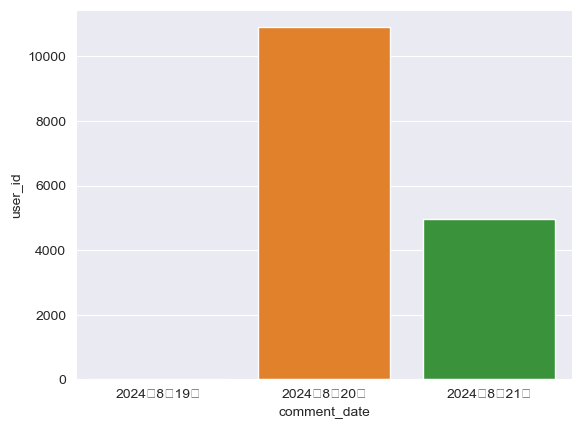

In [12]:
comment_time = data.groupby(by='comment_date', as_index=False)['user_id'].count()
print(comment_time)

sns.barplot(x='comment_date', y='user_id', data=comment_time)


### 总体推荐分析

  recommend comment_date  user_id
2       yes   2024年8月19日        8
0        no   2024年8月20日     1523
3       yes   2024年8月20日     9375
1        no   2024年8月21日     1055
4       yes   2024年8月21日     3900


<Axes: xlabel='comment_date', ylabel='user_id'>

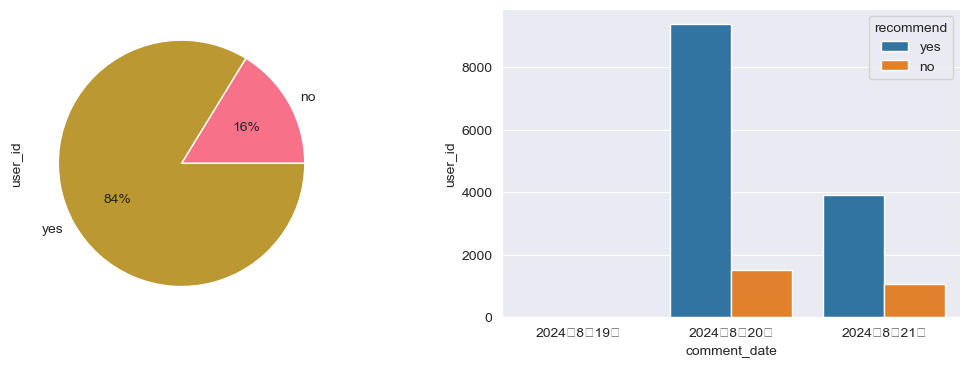

In [13]:
comment_recom_1 = data.groupby(by=['recommend', 'comment_date'], as_index=False)['user_id'].count()
comment_recom_1 = comment_recom_1.sort_values(by=['comment_date'], ascending=True)
comment_recom_1['recommend'] = comment_recom_1['recommend'].map({0: 'no', 1: 'yes'})
comment_recom_2 = data.groupby(by=['recommend'], as_index=False)['user_id'].count()
comment_recom_2['recommend'] = comment_recom_2['recommend'].map({0: 'no', 1: 'yes'})
comment_recom_2 = comment_recom_2.set_index('recommend')
print(comment_recom_1)

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
comment_recom_2.plot(kind='pie', y='user_id', colors=colors, legend=None, autopct='%1.0f%%', ax=axs[0])
sns.barplot(y='user_id', x='comment_date', data=comment_recom_1, hue='recommend',  ax=axs[1])

### 标签系统

In [14]:
# 备份数据
data_cus = data.copy()
# 可视化函数
def tag_visualization(data, tag_name, title1, title2):
    data_1 = data.groupby(by=[tag_name, 'recommend'], as_index=False)['user_id'].count()
    data_1 = pd.merge(data_1[data_1['recommend'] == 1][[tag_name, 'user_id']], data_1[data_1['recommend'] == 0][[tag_name, 'user_id']], how='left', on=tag_name)
    data_1.columns = [tag_name, 'recommend', 'not_recommend']
    data_1['total'] = data_1['recommend'] + data_1['not_recommend']
    data_1['recom_percent%'] = round(data_1['recommend']/data_1['total'], 3)*100
    data_1[tag_name+'_t'] = data_1[tag_name]
    data_1 = data_1.set_index(tag_name+'_t')
    print(data_1)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    data_1.plot(kind='pie', y='total', colors=colors, legend=None, autopct='%1.0f%%', ax=axs[0])
    sns.barplot(x='recommend', y=tag_name, data=data_1, color='blue', label='yes', ax=axs[1])
    sns.barplot(x='not_recommend', y=tag_name, data=data_1, color='pink', label='no', left=data_1['recommend'], ax=axs[1])
    axs[0].set_title(title1)
    axs[1].set_title(title2)
    return data

### 用户等级

            level_tag  recommend  not_recommend  total  recom_percent%
level_tag_t                                                           
0-20             0-20       7589           1585   9174            82.7
20-50           20-50       2665            418   3083            86.4
50-100         50-100       1273            185   1458            87.3
100-200       100-200        493             41    534            92.3
200-300       200-300         71              2     73            97.3
300-400       300-400         26              1     27            96.3
400-500       400-500          2              1      3            66.7
500-600       500-600          6              0      6           100.0
600-700       600-700          2              0      2           100.0


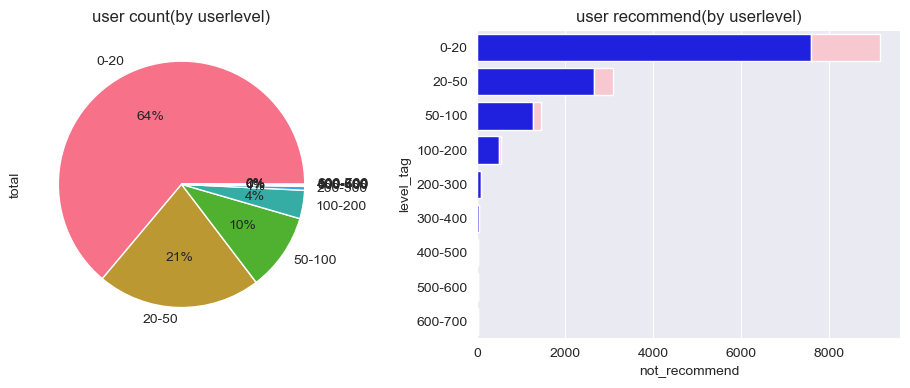

In [15]:
data_cus['level_tag'] = pd.cut(data_cus['user_level'], bins=[0, 20, 50, 100, 200, 300, 400, 500, 600, 700], labels=['0-20', '20-50', '50-100', '100-200', '200-300', '300-400', '400-500', '500-600', '600-700'], right=False)
data_cus = tag_visualization(data_cus, 'level_tag', 'user count(by userlevel)', 'user recommend(by userlevel)')
data['level_tag'] = data_cus['level_tag']

### 用户徽章数

             badge_tag  recommend  not_recommend  total  recom_percent%
badge_tag_t                                                            
None              None       3343            947   4290            77.9
0-20              0-20       6831           1231   8062            84.7
20-50            20-50       1848            261   2109            87.6
50-100          50-100        672            100    772            87.0
100-500        100-500        517             36    553            93.5
500-1000      500-1000         47              2     49            95.9
1000-2000    1000-2000         17              1     18            94.4
2000-3000    2000-3000          6              0      6           100.0


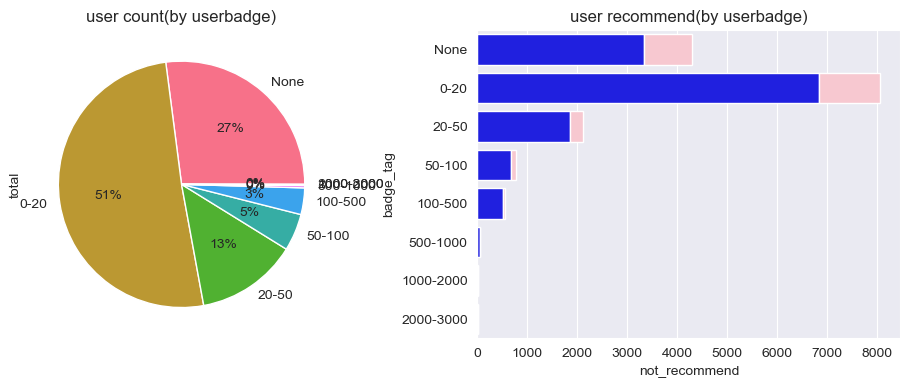

In [16]:
data_cus['badge_tag'] = pd.cut(data_cus['user_badge'], bins=[-1, 0, 20, 50, 100, 500, 1000, 2000, 3000], labels=['None', '0-20', '20-50', '50-100', '100-500', '500-1000', '1000-2000', '2000-3000'], right=False)
data_cus = tag_visualization(data_cus, 'badge_tag', 'user count(by userbadge)', 'user recommend(by userbadge)')
data['badge_tag'] = data_cus['badge_tag']

### 用户游戏数

             game_tag  recommend  not_recommend  total  recom_percent%
game_tag_t                                                            
None             None       3343            947   4290            77.9
0-20             0-20        817            173    990            82.5
20-50           20-50       2167            307   2474            87.6
50-100         50-100       2436            439   2875            84.7
100-500       100-500       3766            609   4375            86.1
500-1000     500-1000        452             70    522            86.6
1000-2000   1000-2000        188             23    211            89.1
2000-3000   2000-3000         52              7     59            88.1


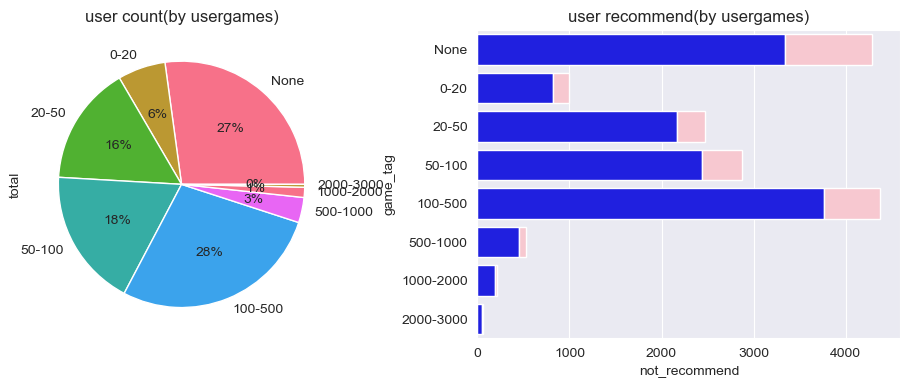

In [31]:
data_cus['game_tag'] = pd.cut(data_cus['user_games'], bins=[-1, 0, 20, 50, 100, 500, 1000, 2000, 3000], labels=['None', '0-20', '20-50', '50-100', '100-500', '500-1000', '1000-2000', '2000-3000'], right=False)
data_cus = tag_visualization(data_cus, 'game_tag', 'user count(by usergames)', 'user recommend(by usergames)')
data['game_tag'] = data_cus['game_tag']

## 用户聚类K-Means

In [18]:
# 抽取模型指标
data.columns
features = data.drop(['user_id', 'user_link', 'user_name', 'user_nationality',
                      'comment_date', 'comment','score', 'level_tag', 'game_tag',
                      'badge_tag'],axis=1)
print(features.columns)


Index(['user_level', 'user_badge', 'user_games', 'recommend'], dtype='object')


聚类簇K值选择

Text(0.5, 1.0, 'Silhouette Coefficient Map')

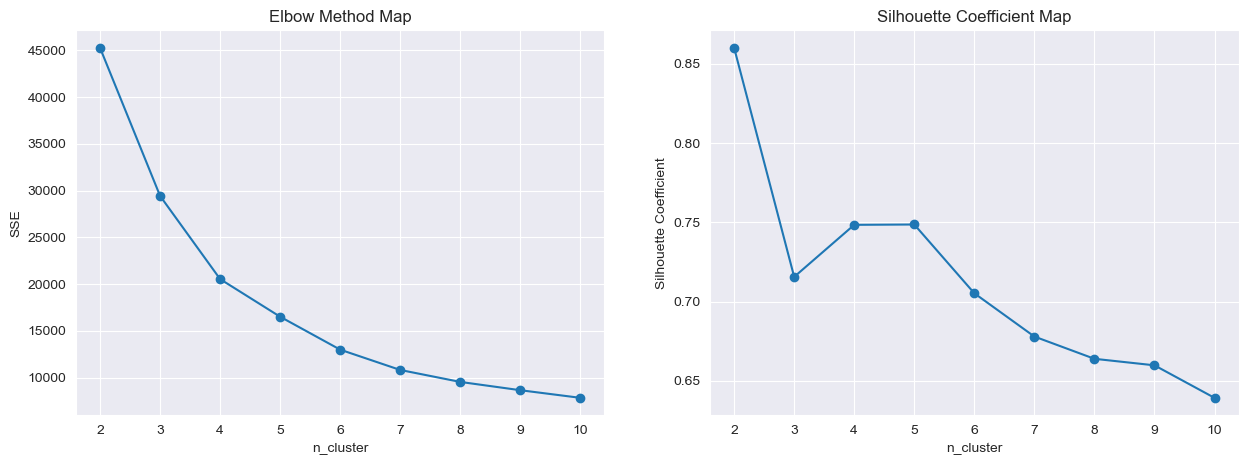

In [19]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

inertia = []
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=15,n_init=10).fit(scaled_features)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, kmeans.labels_))

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.xlabel('n_cluster')
plt.ylabel('SSE')
plt.title('Elbow Method Map')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('n_cluster')
plt.ylabel('Silhouette Coefficient')
plt.title('Silhouette Coefficient Map')

In [20]:
# 使用 K-Means 进行聚类
kmeans = KMeans(n_clusters=4, random_state=15,n_init=10)
kmeans.fit(scaled_features) # 拟合
labels = kmeans.labels_  # 获取聚类结果
data['Cluster'] = kmeans.labels_

Text(0.5, 1.0, 'Cluster Result')

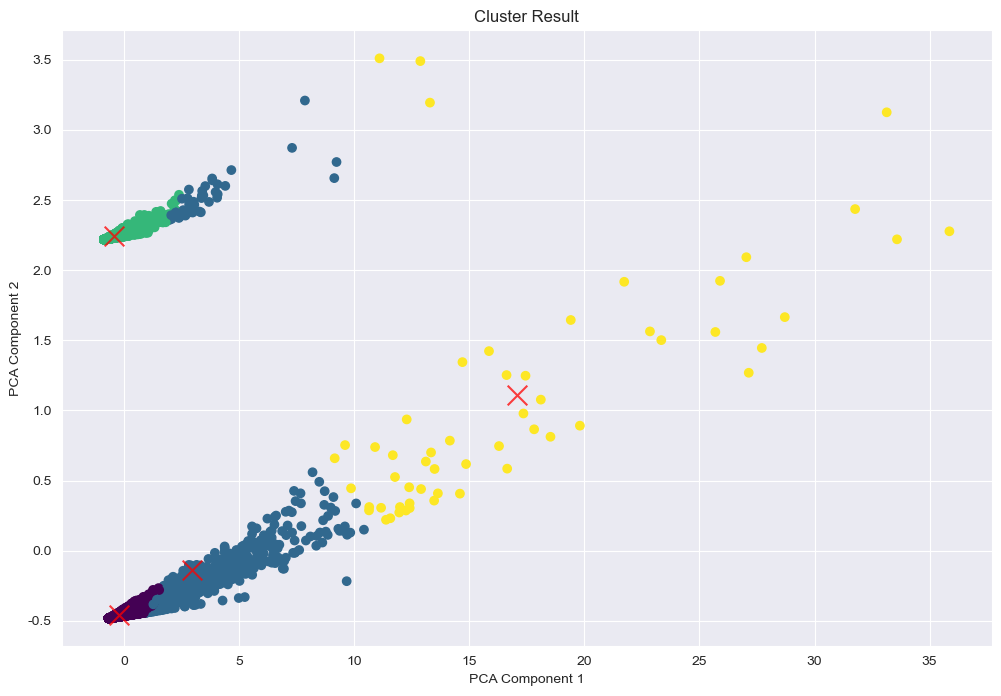

In [21]:
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(scaled_features)
plt.figure(figsize=(12, 8))
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels, cmap='viridis', marker='o')
centers = kmeans.cluster_centers_
reduced_centers = pca.transform(centers)
plt.scatter(reduced_centers[:, 0], reduced_centers[:, 1], c='red', s=200, alpha=0.75, marker='x')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Cluster Result')

In [22]:
# 保存聚类结果
# data.head(3)
data_kmeans = data[['user_id', 'user_link', 'user_name', 'user_nationality',
                    'level_tag', 'user_level', 'badge_tag', 'user_badge',
                    'game_tag', 'user_games', 'Cluster']]
data_kmeans.head(3)
data_kmeans.to_csv('用户标签系统-kmeans聚类.csv', index=False, encoding='utf-8-sig')

## 用户权重

Text(0.5, 1.0, 'user recommend(by cluster)')

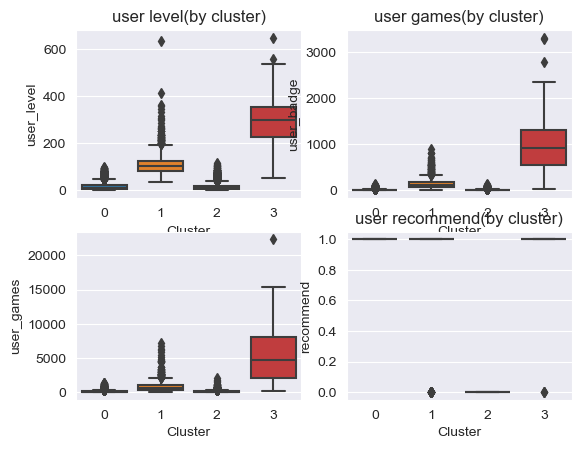

In [23]:
fig, axs = plt.subplots(2, 2)
sns.boxplot(x='Cluster', y='user_level', data=data, ax=axs[0][0])
sns.boxplot(x='Cluster', y='user_badge', data=data, ax=axs[0][1])
sns.boxplot(x='Cluster', y='user_games', data=data, ax=axs[1][0])
sns.boxplot(x='Cluster', y='recommend', data=data, ax=axs[1][1])
axs[0][0].set_title('user level(by cluster)')
axs[0][1].set_title('user badge(by cluster)')
axs[0][1].set_title('user games(by cluster)')
axs[1][1].set_title('user recommend(by cluster)')

In [24]:
cluster0 = data[data['Cluster']==0]
print(cluster0.describe())
cluster1 = data[data['Cluster']==1]
print(cluster1.describe())
cluster2 = data[data['Cluster']==2]
print(cluster2.describe())
cluster3 = data[data['Cluster']==3]
print(cluster3.describe())

         user_level    user_badge    user_games  recommend         score  \
count  12251.000000  12251.000000  12251.000000    12251.0  12251.000000   
mean      15.986287     10.560607     84.575463        1.0     10.093021   
std       16.722825     14.950426    120.342445        0.0      5.543838   
min       -1.000000     -1.000000     -1.000000        1.0      0.100000   
25%        5.000000     -1.000000     -1.000000        1.0      5.900000   
50%       10.000000      6.000000     47.000000        1.0      9.700000   
75%       22.000000     14.000000    113.000000        1.0     13.800000   
max       98.000000    132.000000   1347.000000        1.0    127.200000   

       Cluster  
count  12251.0  
mean       0.0  
std        0.0  
min        0.0  
25%        0.0  
50%        0.0  
75%        0.0  
max        0.0  
        user_level   user_badge   user_games    recommend        score  \
count  1023.000000  1023.000000  1023.000000  1023.000000  1023.000000   
mean    113.00

## 评论文本分析

In [25]:
# 模型数据预处理
cluster_2 = data[data['Cluster'] == 2]
cluster_3 = data[data['Cluster'] == 3]
cluster_0 = data[data['Cluster'] == 0]
cluster_1 = data[data['Cluster'] == 1]
data_sen = pd.concat([data, cluster_3, cluster_3, cluster_3, cluster_1, cluster_1, cluster_0])
data_sen.columns

Index(['user_id', 'user_link', 'user_name', 'user_nationality', 'user_level',
       'user_badge', 'user_games', 'comment_date', 'recommend', 'score',
       'comment', 'level_tag', 'badge_tag', 'game_tag', 'Cluster'],
      dtype='object')

In [26]:
# 读取中文常见停用词
with open('cn_stopwords.txt', 'r', encoding='utf-8') as f:
    stopwords = set(f.readlines())

word_list = []
data_sen['sentiment_score'] = ''
data_sen['sentiment_score_type'] = ''
data_sen['score_r2'] = ''

for i in data_sen.index:
    if str(data_sen['comment'][i]) is not None and str(data_sen['comment'][i]) != '':
        # 创建SnowNLP对象
        s = SnowNLP(str(data_sen['comment'][i]))
        # jieba 分词，统计词频
        words_l = jieba.analyse.textrank(str(data_sen['comment'][i]), allowPOS=('n', 'nr', 'ns', 'nt', 'nz', 'nl', 'vn', 's', 'a', 'ad', 'an','mq'))
        words = [word for word in words_l if word not in stopwords]
        word_list.append(words)
        # SnowNLP 计算文本情感分数
        sentiment_score = s.sentiments
        data_sen['sentiment_score'][i] = sentiment_score
        # 保留分数的两位小数，仅用于协助可视化，不影响模型本身
        data_sen['score_r2'][i] = round(sentiment_score, 2)
        # 设定分数0.6~1为正面评价，0.4~0.6为一般评价，0~0.4为负面评价
        if sentiment_score > 0.6:
            data_sen['sentiment_score_type'][i] = 'positive'
        elif sentiment_score > 0.4:
            data_sen['sentiment_score_type'][i] = 'objective'
        else:
            data_sen['sentiment_score_type'][i] = 'negative'

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\lenovo\AppData\Local\Temp\jieba.cache
Loading model cost 0.729 seconds.
Prefix dict has been built successfully.


## 评论角度倾向

In [27]:
x = []
y = []
for i in range(len(word_list)):
    for j in range(len(word_list[i])):
        if word_list[i][j] != '游戏':
            if word_list[i][j] in x:
                index = x.index(word_list[i][j])
                y[index] += 1
            else:
                x.append(word_list[i][j])
                y.append(1)
word_c_list = list(zip(x, y))
word_c = WordCloud()
word_c.add('', word_c_list, word_size_range=[20, 70],shape='circle')
word_c.render()
word_c.render_notebook()

In [28]:
# 生成词频文件
df_word_cloud = pd.DataFrame({'词语': x, '词频': y})
df_word_cloud.to_csv('词频.csv', index=False, encoding='utf-8-sig')

## 评论情感分析

<Axes: xlabel='score_r2', ylabel='user_id'>

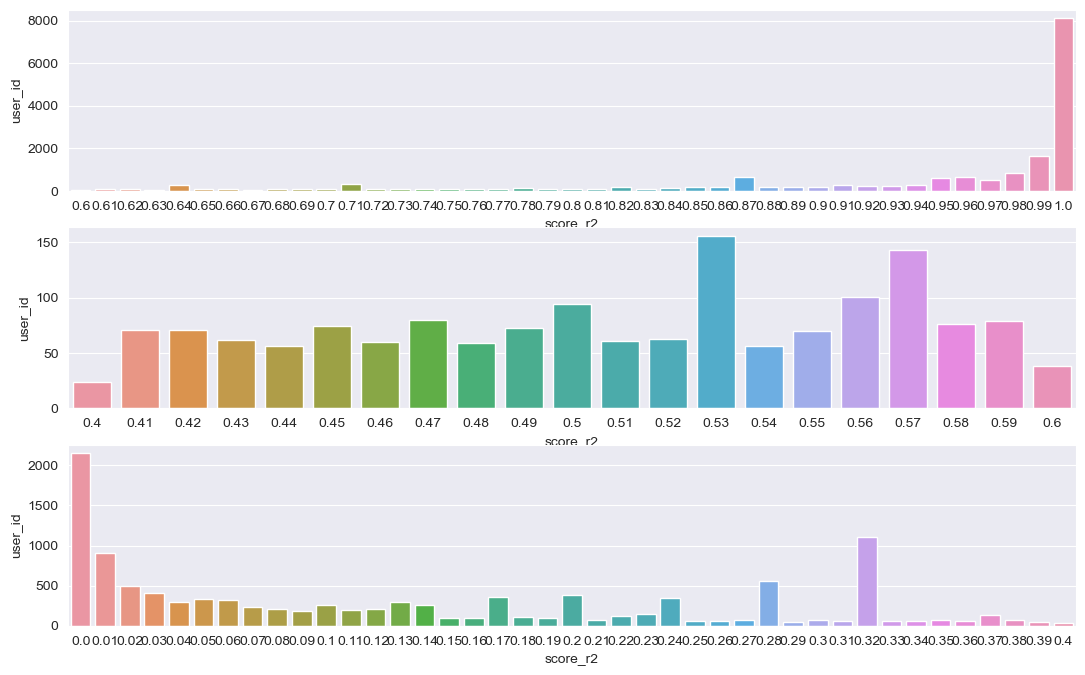

In [29]:
# 评论情感得分可视化
fig, axs = plt.subplots(3,1,figsize=(13,8))
sen_group1 = data_sen.groupby(by=['score_r2', 'sentiment_score_type'], as_index=False)['user_id'].count()
sns.barplot(x='score_r2', y='user_id', data=sen_group1[sen_group1['sentiment_score_type']=='positive'], ax=axs[0])
sns.barplot(x='score_r2', y='user_id', data=sen_group1[sen_group1['sentiment_score_type']=='objective'], ax=axs[1])
sns.barplot(x='score_r2', y='user_id', data=sen_group1[sen_group1['sentiment_score_type']=='negative'], ax=axs[2])

   recommendornot  positive  objective  negative  total
0               0      1053        242      1377   2672
1               1     16551       1325      9774  27650


<Axes: xlabel='recommendornot', ylabel='negative'>

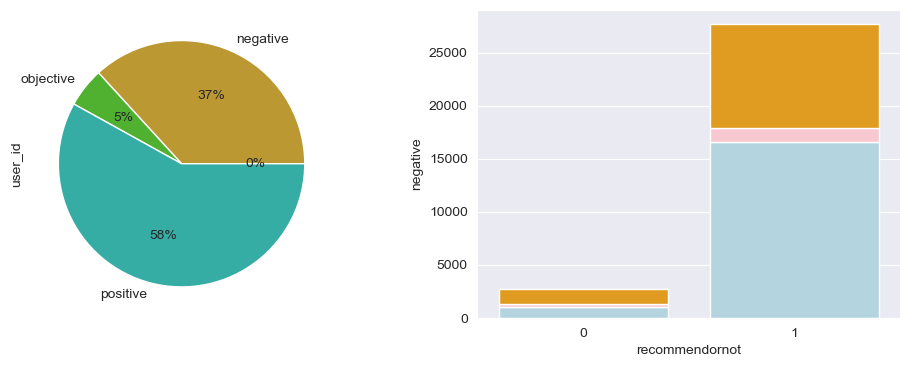

In [30]:
# 评价及推荐关系可视化
sen_group_2 = data_sen.groupby(by='sentiment_score_type', as_index=False)['user_id'].count()
sen_group_2 = sen_group_2.set_index('sentiment_score_type')
sen_group_31 = data_sen[data_sen['sentiment_score_type'] == 'positive'].groupby(by=['recommend'], as_index=False)['user_id'].count()
sen_group_31.columns = ['recommendornot', 'positive']
sen_group_32 = data_sen[data_sen['sentiment_score_type'] == 'objective'].groupby(by=['recommend'], as_index=False)['user_id'].count()
sen_group_32.columns = ['recommendornot', 'objective']
sen_group_33 = data_sen[data_sen['sentiment_score_type'] == 'negative'].groupby(by=['recommend'], as_index=False)['user_id'].count()
sen_group_33.columns = ['recommendornot', 'negative']
sen_group_3 = pd.merge(sen_group_31, sen_group_32, how='left', on='recommendornot')
sen_group_3 = pd.merge(sen_group_3, sen_group_33, how='left', on='recommendornot')
sen_group_3['total'] = sen_group_3['positive'] + sen_group_3['objective'] + sen_group_3['negative']
print(sen_group_3)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sen_group_2.plot(kind='pie', y='user_id', colors=colors, legend=None, autopct='%1.0f%%', ax=axs[0])
sns.barplot(x='recommendornot', y='positive', data=sen_group_3, color='lightblue', label='positive', ax=axs[1])
sns.barplot(x='recommendornot', y='objective', data=sen_group_3, color='pink', label='objective', bottom=sen_group_3['positive'], ax=axs[1])
sns.barplot(x='recommendornot', y='negative', data=sen_group_3, color='orange', label='negative', bottom=sen_group_3['objective']+sen_group_3['positive'], ax=axs[1])